# Realtime decoder timing and throughput analysis

This notebook reads one saved `realtime_decoder` run and answers four questions:

1. How quickly are encoder KDE queries and posterior bins computed?
2. How long after a spike reaches the decoder is its intended posterior available?
3. How many spikes are added, sent, received, late, overwritten, removed by timestamp collision, or used?
4. How do these measurements change as the encoder models grow?

The x-axis is **elapsed wall time**. Counts and rates are grouped into configurable windows. Large mark, likelihood, and posterior arrays are skipped while reading, so the analysis does not load them into memory.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

# Find the helper whether the notebook starts in the repository root or this directory.
candidate_dirs = [Path.cwd() / 'time_analysis', Path.cwd(), Path.cwd().parent / 'time_analysis']
ANALYSIS_DIR = next(
    (path.resolve() for path in candidate_dirs if (path / 'realtime_decoder_performance.py').exists()),
    None,
)
if ANALYSIS_DIR is None:
    raise FileNotFoundError('Could not find time_analysis/realtime_decoder_performance.py')
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from realtime_decoder_performance import (
    aggregate_windows,
    build_analysis_tables,
    export_aggregates,
    headline_summary,
    inspect_binary_header,
    per_trode_summary,
    plot_scaling_analysis,
    plot_time_analysis,
    select_run,
    validation_table,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')


## 1. Settings

Set `RUN_PREFIX` to a saved run prefix, or leave it as `None` to select the newest run with timing files. A five-second aggregation window is a good starting point; increase it for smoother curves.

In [4]:
OUTPUT_DIR = Path('/media/ssd1/decoder_output/Toby/20250316_07_r4')
RUN_PREFIX = None
WINDOW_SECONDS = 5.0
MODEL_SIZE_BINS = 30
SAVE_FIGURES = False
EXPORT_TABLES = False

if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f'Output directory does not exist: {OUTPUT_DIR}')
if WINDOW_SECONDS <= 0:
    raise ValueError('WINDOW_SECONDS must be positive')


In [5]:
selected_prefix, config, available_runs = select_run(OUTPUT_DIR, RUN_PREFIX)
display(available_runs.tail(10))
print(f'\nSelected run: {selected_prefix}')
print(f"Configured source: {config.get('datasource')}")
print(f"Decoder ranks: {config['rank']['decoders']}")
print(f"Encoder ranks: {config['rank']['encoders']}")


,prefix,config_path,modified,state_files,encoder_timing_files,decoder_timing_files,has_posterior_timing
0,20260825_193823_Toby_hex_realtime_decoding,/media/ssd1/decoder_output/Toby/20250316_07_r4...,2026-08-26 02:38:23.029429197,11,8,8,True



Selected run: 20260825_193823_Toby_hex_realtime_decoding
Configured source: trodes
Decoder ranks: [1]
Encoder ranks: [4, 5, 6, 7, 8, 9, 10, 11]


## 2. How the decoded outputs are read

A run is reconstructed from four output families:

- `*.config.yaml`: the copied run configuration and rank assignments.
- `*.state.bin_rec`: binary records. Record ID 3 contains amplitude-qualified encoder events; ID 4 contains decoder-bin metadata and the saved posterior.
- `*_encoder_trode_*.timing.npz` and `*_decoder_trode_*.timing.npz`: per-spike wall-clock timestamps.
- `*_decoder_rank_*.timing.npz`: posterior start/end timestamps for each decoder bin.

The helper parses the JSON header at the beginning of each binary record file, unpacks only the scalar prefix, then seeks over the 12-D mark and 49-bin histogram/posterior vectors. Repeated `(nTrode, timestamp)` events receive an occurrence index before joins, preventing accidental many-to-many row multiplication.

In [6]:
# Inspect the actual schemas used by this run before reading its records.
wanted_ranks = {int(config['rank']['decoders'][0]), int(config['rank']['encoders'][0])}
schema_rows = []
for path in sorted(OUTPUT_DIR.glob(f'{selected_prefix}.*.state.bin_rec')):
    header = inspect_binary_header(path)
    rank = int(header['mpi_rank'])
    if rank not in wanted_ranks:
        continue
    formats = header.get('rec_formats', {})
    labels = header.get('rec_labels', {})
    for record_id in (3, 4):
        record_labels = labels.get(str(record_id), labels.get(record_id))
        if record_labels is None:
            continue
        scalar_limit = 12 if record_id == 3 else 20
        schema_rows.append({
            'file': path.name,
            'MPI rank': rank,
            'record ID': record_id,
            'scalar fields read': ', '.join(record_labels[:scalar_limit]),
            'full struct format': formats.get(str(record_id), formats.get(record_id)),
        })
display(pd.DataFrame(schema_rows))

timing_patterns = {
    'encoder KDE': f'{selected_prefix}_encoder_trode_*.timing.npz',
    'decoder receive': f'{selected_prefix}_decoder_trode_*.timing.npz',
    'posterior': f'{selected_prefix}_decoder_rank_*.timing.npz',
}
timing_rows = []
for source, pattern in timing_patterns.items():
    path = next(iter(sorted(OUTPUT_DIR.glob(pattern))), None)
    if path is not None:
        with np.load(path, allow_pickle=False) as archive:
            timing_rows.append({
                'source': source,
                'example file': path.name,
                'rows': len(archive['timings']),
                'fields': ', '.join(archive['timings'].dtype.names),
            })
display(pd.DataFrame(timing_rows))


,file,MPI rank,record ID,scalar fields read,full struct format
0,20260825_193823_Toby_hex_realtime_decoding.01....,1,3,"timestamp, elec_grp_id, position, velocity, en...",qidd?qqq?d?idddddddddddddddddddddddddddddddddd...
1,20260825_193823_Toby_hex_realtime_decoding.01....,1,4,"timestamp, bin_timestamp_l, bin_timestamp_r, v...",qqqddddddddqqqqqqqd?dddddddddddddddddddddddddd...
2,20260825_193823_Toby_hex_realtime_decoding.04....,4,3,"timestamp, elec_grp_id, position, velocity, en...",qidd?qqq?d?idddddddddddddddddddddddddddddddddd...
3,20260825_193823_Toby_hex_realtime_decoding.04....,4,4,"timestamp, bin_timestamp_l, bin_timestamp_r, v...",qqqddddddddqqqqqqqd?dddddddddddddddddddddddddd...


,source,example file,rows,fields
0,encoder KDE,20260825_193823_Toby_hex_realtime_decoding_enc...,158391,"elec_grp_id, timestamp, t_send_data, t_recv_da..."
1,decoder receive,20260825_193823_Toby_hex_realtime_decoding_dec...,158390,"elec_grp_id, timestamp, t_decoder"
2,posterior,20260825_193823_Toby_hex_realtime_decoding_dec...,199044,"decoder_rank, bin_timestamp_l, bin_timestamp_r..."


## 3. Load and align the run

This creates three main data frames: `encoder_events`, `sent_spikes`, and `posterior_bins`. The load progress printed below is also a useful check that every configured rank has a record file.

In [7]:
tables = build_analysis_tables(OUTPUT_DIR, selected_prefix, config)
encoder_events = tables['encoder_events']
sent_spikes = tables['sent_spikes']
posterior_bins = tables['posterior_bins']

table_inventory = pd.DataFrame([
    {'table': 'encoder_events', 'rows': len(encoder_events), 'memory_MB': encoder_events.memory_usage(deep=True).sum() / 1e6},
    {'table': 'sent_spikes', 'rows': len(sent_spikes), 'memory_MB': sent_spikes.memory_usage(deep=True).sum() / 1e6},
    {'table': 'posterior_bins', 'rows': len(posterior_bins), 'memory_MB': posterior_bins.memory_usage(deep=True).sum() / 1e6},
])
display(table_inventory)


Read 165,893 encoder records from rank 4
Read 256,148 encoder records from rank 5
Read 193,755 encoder records from rank 6
Read 241,853 encoder records from rank 7
Read 181,916 encoder records from rank 8
Read 196,882 encoder records from rank 9
Read 129,196 encoder records from rank 10
Read 57,345 encoder records from rank 11
Read 199,044 decoder-bin records from rank 1


,table,rows,memory_MB
0,encoder_events,1422988,210.6024
1,sent_spikes,1319576,532.1162
2,posterior_bins,199044,31.2503


In [8]:
# Small, readable samples of the fields used in the analysis.
display(encoder_events[[
    'elapsed_s', 'timestamp', 'elec_grp_id', 'encode_spike', 'kde_sent',
    'model_size_before', 'model_size_after',
]].head())
display(sent_spikes[[
    'elapsed_s', 'timestamp', 'elec_grp_id', 'kde_ms', 'decoder_received',
    'deadline_slack_ms', 'decoder_to_posterior_ms', 'status',
]].head())
display(posterior_bins[[
    'elapsed_s', 'decoder_rank', 'bin_timestamp_l', 'bin_timestamp_r',
    'spike_count', 'posterior_ms', 'dropped_spikes', 'duplicated_spikes',
]].head())


,elapsed_s,timestamp,elec_grp_id,encode_spike,kde_sent,model_size_before,model_size_after
0,0.0002,732638390,1,False,False,0,0
1,0.0012,732638697,1,False,False,0,0
2,0.0058,732640011,1,False,False,0,0
3,0.0079,732640645,1,False,False,0,0
4,0.0091,732640976,1,False,False,0,0


,elapsed_s,timestamp,elec_grp_id,kde_ms,decoder_received,deadline_slack_ms,decoder_to_posterior_ms,status
0,1.4728,732685285,1,0.4854,True,10.2828,10.3900,used
1,1.6557,732690788,1,0.2292,True,7.7865,7.8881,used
2,1.7178,732692647,1,0.2149,True,5.5798,5.6883,used
3,1.8488,732696579,1,0.2084,True,6.5101,6.6173,used
4,1.8867,732697697,1,0.2228,True,4.7181,4.8243,used


,elapsed_s,decoder_rank,bin_timestamp_l,bin_timestamp_r,spike_count,posterior_ms,dropped_spikes,duplicated_spikes
0,0.0010,1,732637940,732638120,0,0.2090,0,0
1,0.0015,1,732638120,732638300,0,0.1069,0,0
2,0.0022,1,732638300,732638480,0,0.0966,0,0
3,0.0029,1,732638480,732638660,0,0.0944,0,0
4,0.0035,1,732638660,732638840,0,0.0938,0,0


## 4. Validate the reconstruction

Do not interpret plots until these checks pass. In particular, the derived `used_in_posterior` classification is replayed with the decoder's current timestamp-collision behavior and compared against the recorded spike count in every posterior bin.

In [9]:
quality_checks = validation_table(tables)
display(quality_checks)
if not quality_checks['passes'].all():
    warnings.warn('One or more validation checks failed. Treat downstream metrics cautiously.')
else:
    print('All reconstruction checks passed.')


,check,observed,expected,passes
0,Encoder additions match saved growth for every...,8,8,True
1,KDE-sent ID-3 records retained,1319576,1319576,True
2,KDE-sent records matched encoder timing rows,1319576,1319576,True
3,Received flags equal decoder timing rows,1319569,1319569,True
4,Posterior timing rows matched decoder records,199044,199044,True
5,Posterior durations are nonnegative,199044,199044,True
6,KDE durations are nonnegative,1319576,1319576,True
7,Derived used count matches every posterior bin,199044,199044,True
8,Derived timestamp removals match every posteri...,199044,199044,True


All reconstruction checks passed.


## 5. Whole-run metrics

`posterior_ms` is the core `compute_posterior` duration. `decoder_to_posterior_ms` is the requested lag from decoder receipt to the end of the intended posterior, and is defined only for on-time spikes. For late spikes, `late_tardiness_ms` reports how far after the deadline they arrived instead of producing a misleading negative lag.

In [10]:
summary = headline_summary(tables, config)
display(summary)


,metric,value,unit
0,Run duration,46.0540,min
1,Amplitude-qualified spikes,"1,422,988.0000",count
2,Spikes added to encoder models,"744,218.0000",count
3,Joint-probability messages sent,"1,319,576.0000",count
4,Messages received by decoder,"1,319,569.0000",count
5,Messages received within recorded bins,"719,493.0000",count
6,Spikes used in posterior bins,"278,409.0000",count
7,Derived late arrivals,"202,116.0000",count
8,Derived late-arrival fraction,28.0914,%
9,Unmatched sent messages,7.0000,count


In [11]:
qualified_count = len(encoder_events)
sent_count = len(sent_spikes)
encoder_outcomes = pd.DataFrame({
    'outcome': ['KDE sent', 'KDE rejected / no message'],
    'count': [int(encoder_events['kde_sent'].sum()), int((~encoder_events['kde_sent']).sum())],
})
encoder_outcomes['percent_of_amplitude_qualified'] = 100 * encoder_outcomes['count'] / qualified_count
decoder_outcomes = sent_spikes['status'].value_counts().rename_axis('outcome').reset_index(name='count')
decoder_outcomes['percent_of_sent'] = 100 * decoder_outcomes['count'] / sent_count
print('Encoder query outcomes')
display(encoder_outcomes)
print('Mutually exclusive outcomes for messages sent toward the decoder')
display(decoder_outcomes)


Encoder query outcomes


,outcome,count,percent_of_amplitude_qualified
0,KDE sent,1319576,92.7328
1,KDE rejected / no message,103412,7.2672


Mutually exclusive outcomes for messages sent toward the decoder


,outcome,count,percent_of_sent
0,outside_recorded_bins,600076,45.4749
1,used,278409,21.0984
2,buffer_overwritten,214173,16.2304
3,late,202116,15.3167
4,duplicate_removed,24795,1.8790
5,transport_missing,7,0.0005


## 6. Aggregate through time and plot the main dashboard

Rates are counts divided by the actual wall-time window width. Model size is the last observed size in a window, forward-filled separately for each nTrode. Utilization is a lower bound: encoder timing contains successful KDE calls only, and decoder timing ends immediately after core posterior computation.

In [12]:
aggregates = aggregate_windows(tables, WINDOW_SECONDS)
windows = aggregates['windows']
growth = aggregates['growth']
print(f"Created {len(windows):,} windows of {WINDOW_SECONDS:g} seconds.")
display(windows.head())


Created 553 windows of 5 seconds.


,window,elapsed_s,elapsed_min,amplitude_qualified,model_added,kde_sent,kde_rejected,decoder_received,covered_received,late,on_time,unmatched_receive,outside_recorded_bins,buffer_overwritten,timestamp_collisions,used_spikes,recorded_used_spikes,recorded_timestamp_collisions,reported_drops,amplitude_qualified_rate,model_added_rate,kde_sent_rate,kde_rejected_rate,decoder_received_rate,covered_received_rate,...,source_to_encoder_p99,encoder_to_decoder_p50,encoder_to_decoder_p95,encoder_to_decoder_p99,decoder_to_posterior_p50,decoder_to_posterior_p95,decoder_to_posterior_p99,end_to_end_p50,end_to_end_p95,end_to_end_p99,deadline_slack_p05,deadline_slack_p50,late_tardiness_p50,late_tardiness_p95,posterior_p50,posterior_p95,posterior_p99,late_cumulative,unmatched_cumulative,received_cumulative,late_percent_cumulative,encoder_busy_max_pct,encoder_busy_median_pct,decoder_busy_max_pct,decoder_busy_median_pct
0,0,2.5000,0.0417,5533,4521,1550,3983,1550,1550,0,1550,0,0,0,6,1544,1541,6.0000,0.0000,"1,106.6000",904.2000,310.0000,796.6000,310.0000,310.0000,...,0.5290,0.0131,0.0378,0.1380,7.9896,10.8814,11.0774,8.3933,11.2917,11.4882,5.3708,7.8816,NaN,NaN,0.1040,0.1154,0.1227,0,0,1550,0.0000,2.9622,0.2853,1.7743,1.7743
1,1,7.5000,0.1250,4064,244,2203,1861,2204,2204,0,2204,0,0,0,17,2187,2184,17.0000,5.0000,812.8000,48.8000,440.6000,372.2000,440.8000,440.8000,...,0.4097,0.0118,0.0220,0.0993,7.9310,10.8469,11.0165,8.3535,11.2890,11.4293,5.4965,7.8189,NaN,NaN,0.1057,0.1175,0.1255,0,0,3754,0.0000,6.3598,0.4133,1.7771,1.7771
2,2,12.5000,0.2083,5333,2345,2753,2580,2753,2753,0,2753,0,0,0,52,2701,2702,52.0000,9.0000,"1,066.6000",469.0000,550.6000,516.0000,550.6000,550.6000,...,0.4977,0.0118,0.0212,0.0847,7.8973,10.8109,10.9768,8.3756,11.2719,11.4171,5.4508,7.7865,NaN,NaN,0.1084,0.1219,0.1304,0,0,6507,0.0000,7.0112,0.8306,1.8221,1.8221
3,3,17.5000,0.2917,4942,2976,3205,1737,3204,3204,0,3204,0,0,0,56,3148,3149,56.0000,5.0000,988.4000,595.2000,641.0000,347.4000,640.8000,640.8000,...,0.4831,0.0120,0.0200,0.0652,7.8513,10.7686,10.9582,8.3717,11.2937,11.4524,5.4163,7.7395,NaN,NaN,0.1113,0.1246,0.1312,0,0,9711,0.0000,9.9358,1.1723,1.8679,1.8679
4,4,22.5000,0.3750,4190,928,2756,1434,2758,2758,0,2758,0,0,0,66,2692,2689,66.0000,15.0000,838.0000,185.6000,551.2000,286.8000,551.6000,551.6000,...,0.4817,0.0113,0.0187,0.0448,7.8661,10.7728,10.9382,8.3973,11.3214,11.4700,5.3828,7.7563,NaN,NaN,0.1083,0.1219,0.1299,0,0,12469,0.0000,11.0499,0.6776,1.8232,1.8232


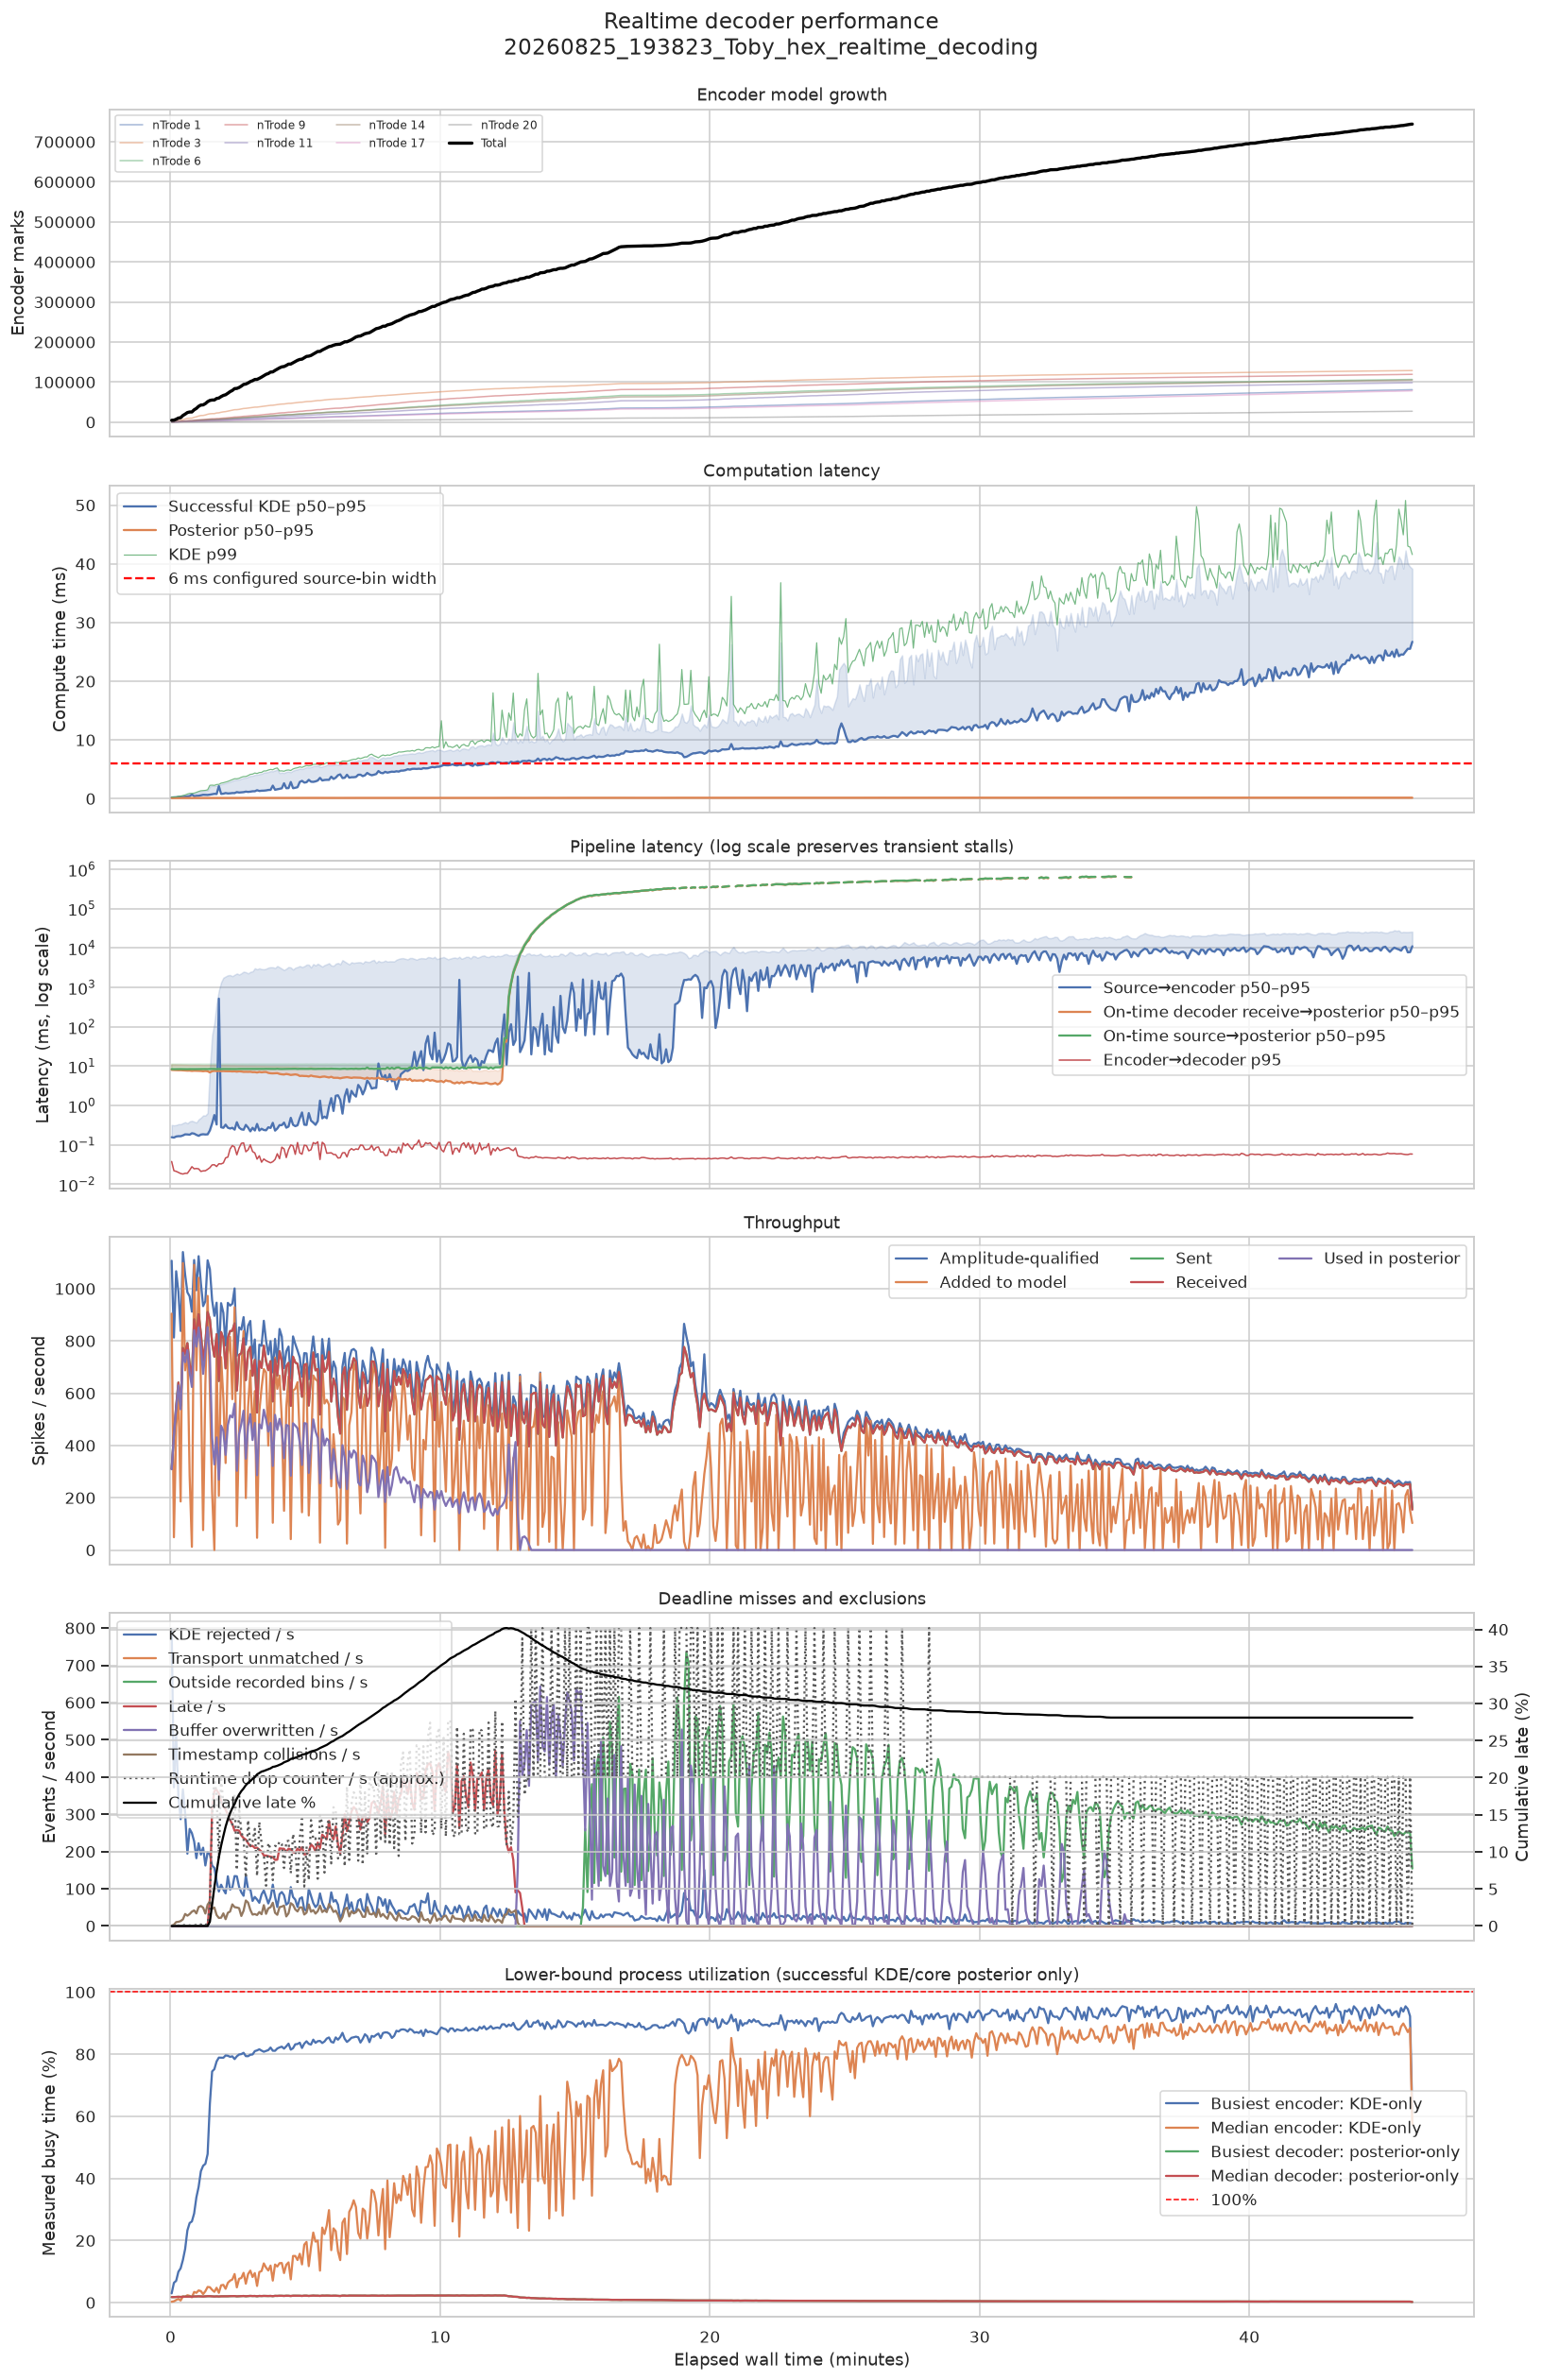

In [13]:
time_figure, time_axes = plot_time_analysis(aggregates, config, selected_prefix)
plt.show()


## 7. Scaling with model size and spike load

The first panel tests whether KDE service time grows with the number of marks in each nTrode's model. The second tests core posterior computation against spikes actually used per bin. The third shows the fraction of arrivals that missed their intended posterior start as the relevant encoder model grew.

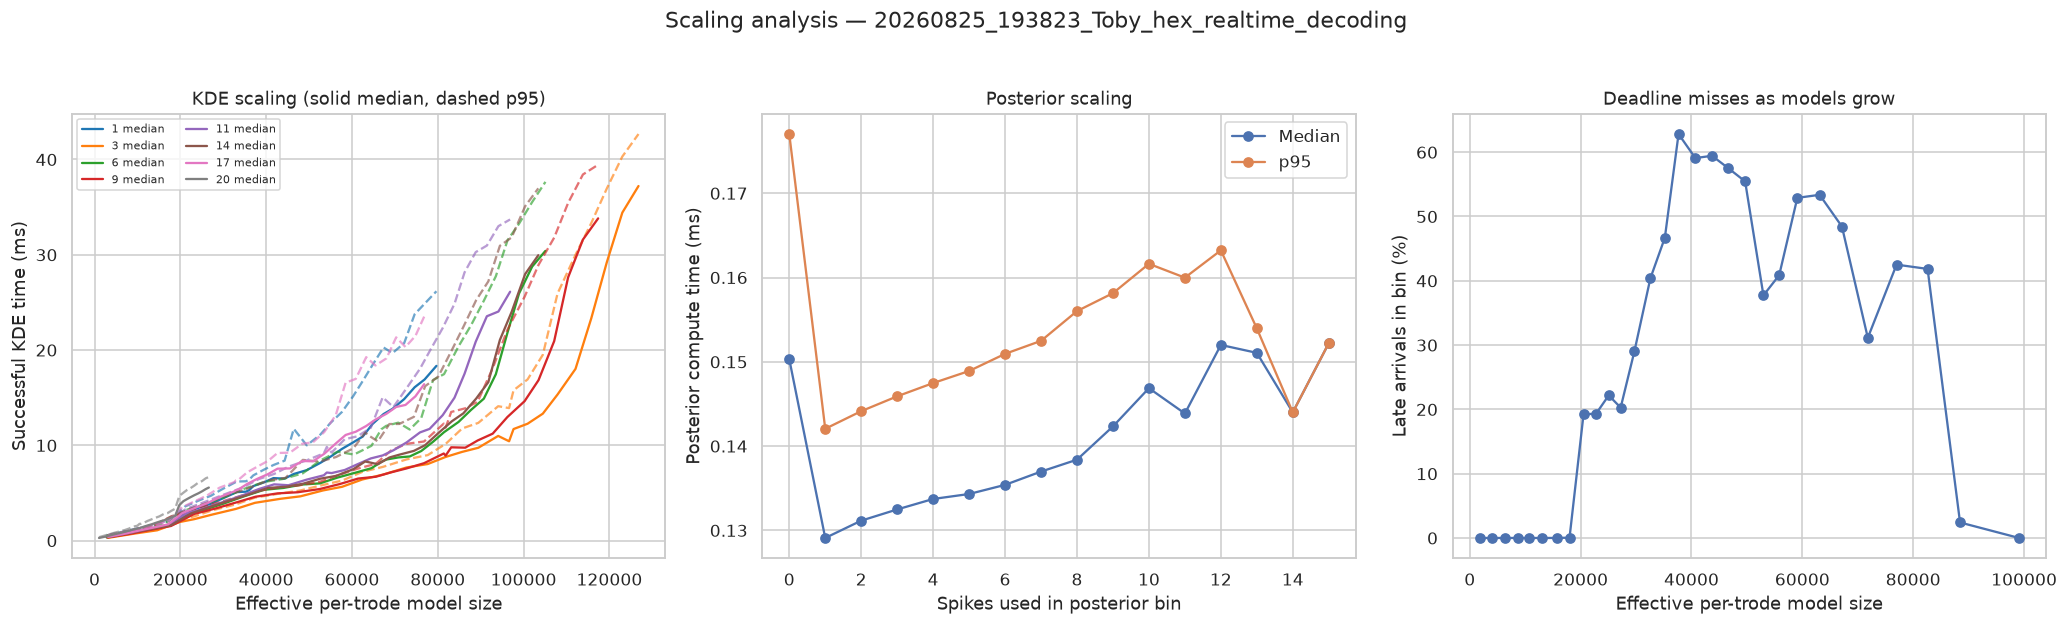

In [14]:
scaling_figure, scaling_axes = plot_scaling_analysis(
    tables, selected_prefix, model_bins=MODEL_SIZE_BINS
)
plt.show()


## 8. Compare the beginning and end of the run

This compact comparison makes growth-related slowdown easy to see without estimating a regression model. The windows are the first and last ten wall-clock minutes (or the available duration for a short run).

In [15]:
run_end_s = max(float(sent_spikes['elapsed_s'].max()), float(posterior_bins['elapsed_s'].max()))
segments = {
    'first 10 min': (0.0, min(600.0, run_end_s)),
    'last 10 min': (max(0.0, run_end_s - 600.0), run_end_s + 1e-9),
}
comparison_rows = []
for label, (left_s, right_s) in segments.items():
    spikes = sent_spikes[sent_spikes['elapsed_s'].between(left_s, right_s, inclusive='left')]
    bins = posterior_bins[posterior_bins['elapsed_s'].between(left_s, right_s, inclusive='left')]
    events = encoder_events[encoder_events['elapsed_s'].between(left_s, right_s, inclusive='left')]
    covered = spikes['decoder_received'] & spikes['in_bin_coverage']
    comparison_rows.append({
        'segment': label,
        'marks added': int(events['encode_spike'].sum()),
        'median model size before query': spikes['effective_model_size'].median(),
        'KDE median ms': spikes['kde_ms'].median(),
        'KDE p95 ms': spikes['kde_ms'].quantile(0.95),
        'posterior median ms': bins['posterior_ms'].median(),
        'posterior p95 ms': bins['posterior_ms'].quantile(0.95),
        'receive-to-posterior median ms': spikes.loc[spikes['on_time'], 'decoder_to_posterior_ms'].median(),
        'late percent': 100 * spikes['late'].sum() / covered.sum() if covered.sum() else np.nan,
    })
display(pd.DataFrame(comparison_rows))


,segment,marks added,median model size before query,KDE median ms,KDE p95 ms,posterior median ms,posterior p95 ms,receive-to-posterior median ms,late percent
0,first 10 min,294119,"21,441.0000",2.5703,6.3925,0.1300,0.1453,6.4082,34.9472
1,last 10 min,83818,"93,537.0000",20.9792,37.3922,0.1664,0.1873,NaN,NaN


## 9. Per-nTrode summary

In [16]:
trode_summary = per_trode_summary(tables)
display(trode_summary.sort_values('late_percent', ascending=False))


,elec_grp_id,amplitude_qualified,model_added,final_model_size,kde_sent,decoder_received,covered_received,unmatched,late,late_percent,buffer_overwritten,timestamp_collision_removed,used_in_posterior,kde_median_ms,kde_p95_ms,kde_p99_ms
1,3,256148,128783,128783,233352,233351,165063,1,107102,64.8855,28319,664,28978,7.8624,34.1020,39.6472
3,9,241853,119288,119288,212506,212505,135940,1,54591,40.1582,35147,2029,44173,7.3955,31.5247,36.9594
2,6,193755,106555,106555,188311,188310,105386,1,18864,17.8999,33354,2709,50459,7.8109,29.0675,34.2516
5,14,196882,104966,104966,184974,184973,98825,1,14449,14.6208,32895,5356,46125,7.9819,28.2180,34.0559
4,11,181916,98355,98355,171628,171627,83730,1,6173,7.3725,30872,4395,42290,7.5316,26.1233,31.5001
0,1,165893,81024,81024,158391,158390,65637,1,753,1.1472,26442,3120,35322,6.4857,18.6189,23.8625
6,17,129196,78137,78137,116229,116228,45245,1,184,0.4067,18242,3697,23122,7.0423,16.8986,21.7329
7,20,57345,27110,27110,54185,54185,19667,0,0,0.0000,8902,2825,7940,1.7962,5.5642,6.3051


## 10. Optional exports

Set the flags in the settings cell to save compact CSV tables and/or PNG figures under `OUTPUT_DIR/performance_analysis/<run prefix>/`. Raw event tables are deliberately not exported because they can be very large.

In [15]:
analysis_output = OUTPUT_DIR / 'performance_analysis' / selected_prefix
if EXPORT_TABLES:
    analysis_output = export_aggregates(
        OUTPUT_DIR, selected_prefix, aggregates, summary, quality_checks, trode_summary
    )
    print(f'Exported tables to {analysis_output}')
if SAVE_FIGURES:
    analysis_output.mkdir(parents=True, exist_ok=True)
    time_figure.savefig(analysis_output / 'performance_over_time.png', dpi=160, bbox_inches='tight')
    scaling_figure.savefig(analysis_output / 'performance_scaling.png', dpi=160, bbox_inches='tight')
    print(f'Saved figures to {analysis_output}')
if not EXPORT_TABLES and not SAVE_FIGURES:
    print('Exports disabled; results remain in this notebook only.')


Exports disabled; results remain in this notebook only.


## Interpretation limits

- ID 3 contains **amplitude-qualified events**, not every raw Trodes spike. Below-threshold source spikes cannot be counted from the current files.
- KDE timing is saved only for successful joint-probability queries. Rejected queries are counted, but their execution duration is unavailable.
- `t_end_post` is recorded immediately after `compute_posterior`; credible intervals, MPI sends, GUI work, and record writes are not included in `posterior_ms`.
- A spike is late when `t_decoder >= t_start_post` for its half-open source bin `[left, right)`. It cannot enter that already-started posterior.
- The derived outcome classification is preferred over `dropped_spikes`. The runtime counter is a periodic circular-buffer audit, misses the final partial audit cycle, and is therefore labeled approximate.
- Timestamp collision removal occurs across all nTrodes assigned to a decoder. Current code retains one event when multiplicity is two and removes all when multiplicity is three or more.
- The 6 ms reference is the configured **source-bin width**. The observed wall-bin interval and estimated playback speed are reported separately.

For complete source-drop accounting in future runs, add a unique event ID and timing record before amplitude filtering, time failed KDE calls, and record a final decoder-buffer audit at shutdown.